# ML Training Pipeline untuk HydroSense AI

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os
import m2cgen as m2c

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor

plt.style.use('ggplot')
sns.set_palette('viridis')

## 2. Data Loading

In [2]:
data_dir = r"D:\DATA\Kuliah\SEMESTER 4\Perancangan Aplikasi Sains Data\data"
all_files = glob.glob(os.path.join(data_dir, "*.csv"))

df_list = []
for file in all_files:
    try:
        # File NASA POWER memiliki 9 baris metadata/header text
        df = pd.read_csv(file, skiprows=9)
        df_list.append(df)
    except Exception as e:
        print(f"Error membaca {file}: {e}")

data = pd.concat(df_list, ignore_index=True)
print(f"Total baris data: {len(data)}")
print(data.head())

Total baris data: 34215
   LAT      LON  YEAR  DOY  PRECTOTCORR
0 -8.0  111.250  2020    1        15.86
1 -8.0  111.875  2020    1        21.10
2 -8.0  112.500  2020    1        16.67
3 -7.5  111.250  2020    1        13.03
4 -7.5  111.875  2020    1         9.91


## 3. Data Preprocessing & Feature Engineering

In [3]:
# Konversi waktu
data['Date'] = pd.to_datetime(data['YEAR'].astype(str) + '-' + data['DOY'].astype(str), format='%Y-%j')

# Memilih fitur (Karena file CSV hanya memiliki LAT, LON, YEAR, DOY)
features = ['LAT', 'LON', 'YEAR', 'DOY'] 
target = 'PRECTOTCORR'

df_clean = data[features + [target]].dropna()

X = df_clean[features]
y = df_clean[target]

print(f"Dimensi X: {X.shape}")
print(f"Dimensi y: {y.shape}")

Dimensi X: (34215, 4)
Dimensi y: (34215,)


## 4. Exploratory Data Analysis (EDA)

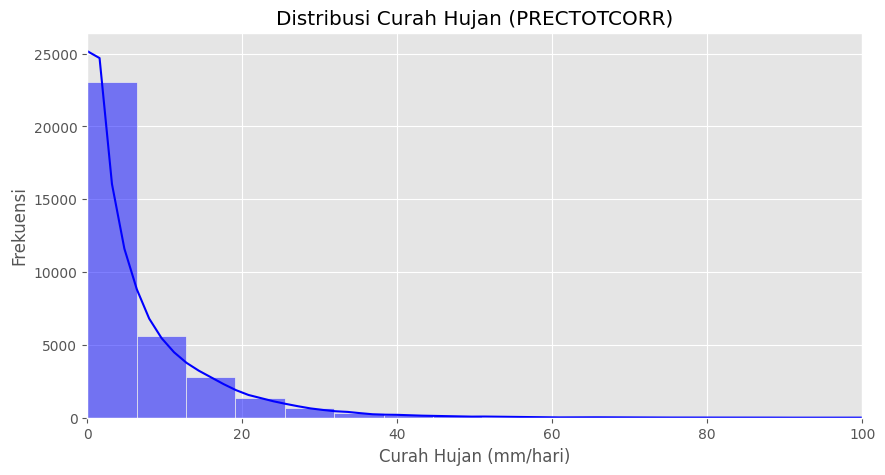

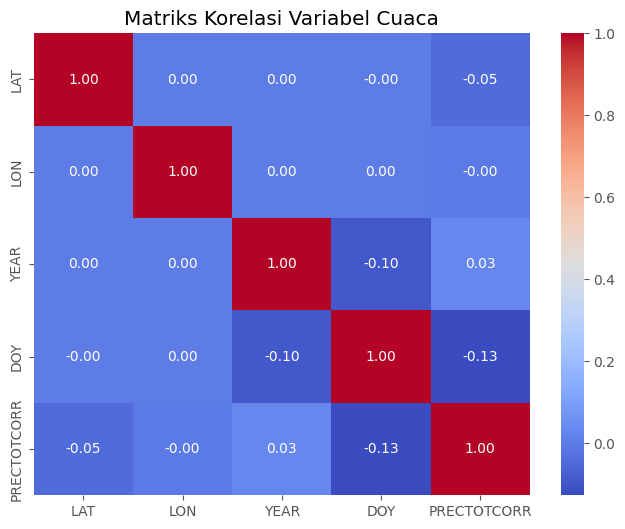

In [4]:
# Plot Distribusi Curah Hujan
plt.figure(figsize=(10, 5))
sns.histplot(y, bins=50, kde=True, color='blue')
plt.title("Distribusi Curah Hujan (PRECTOTCORR)")
plt.xlabel("Curah Hujan (mm/hari)")
plt.ylabel("Frekuensi")
plt.xlim(0, 100)
plt.show()

# Plot Matriks Korelasi
plt.figure(figsize=(8, 6))
correlation = df_clean.corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matriks Korelasi Variabel Cuaca")
plt.show()

## 5. Train/Test Split

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training data: {X_train.shape[0]} baris")
print(f"Testing data: {X_test.shape[0]} baris")

Training data: 27372 baris
Testing data: 6843 baris


## 6. Training Model

In [6]:
xgb_model = XGBRegressor(n_estimators=50, max_depth=4, learning_rate=0.1, random_state=42)

print("Memulai proses training XGBoost...")
xgb_model.fit(X_train, y_train)
print("Training Selesai!")

Memulai proses training XGBoost...
Training Selesai!


## 7. Evaluasi Model

=== Hasil Evaluasi Model ===
Mean Squared Error (MSE)   : 59.56
Mean Absolute Error (MAE)  : 4.67 mm
R-squared Score (R2)       : 0.29


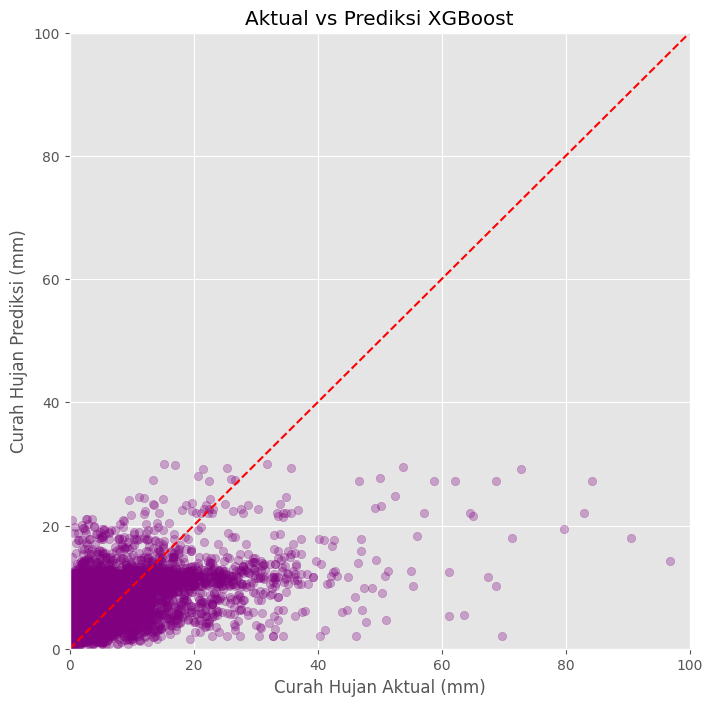

In [7]:
y_pred = xgb_model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("=== Hasil Evaluasi Model ===")
print(f"Mean Squared Error (MSE)   : {mse:.2f}")
print(f"Mean Absolute Error (MAE)  : {mae:.2f} mm")
print(f"R-squared Score (R2)       : {r2:.2f}")

plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred, alpha=0.3, color='purple')
plt.plot([0, 100], [0, 100], 'r--')
plt.title("Aktual vs Prediksi XGBoost")
plt.xlabel("Curah Hujan Aktual (mm)")
plt.ylabel("Curah Hujan Prediksi (mm)")
plt.xlim(0, 100)
plt.ylim(0, 100)
plt.show()

## 8. Export Model to Python Code (m2cgen)
Menggunakan m2cgen untuk menerjemahkan model ke native Python code

In [8]:
print("Mengekspor model menggunakan m2cgen...")
python_code = m2c.export_to_python(xgb_model)

output_path = "m2cgen_inference.py"
with open(output_path, "w") as f:
    f.write(python_code)

print(f"Selesai! Fungsi if-else murni berhasil diekspor ke {output_path}.")

Mengekspor model menggunakan m2cgen...
Selesai! Fungsi if-else murni berhasil diekspor ke m2cgen_inference.py.
